# 1.9 Three-Way Equilibrium Models (Glamsterdam)

Notebook 1.7 solves the Glamsterdam equilibrium base fee with the nested
state-versus-rest demand system. This notebook re-solves the same problem with
the February–May 2026 calibrated accounting panel and two three-resource
demand specifications from notebook 1.8.

## Central Demand System: Independent Isoelastic Curves

For execution, data, and state,

$$
q_i(r_i) = q_i^0 r_i^{-\epsilon_i},
\qquad
r_i = m_i \frac{b}{b_{\text{ref}}}.
$$

The 35-day clean-event estimates from 1.8 provide the headline elasticities.
The 21-day and 60-day calibrations carry the event-window uncertainty into the
equilibrium results. The central execution multiplier comes from notebook 1.10,
which replays the same February–May activity under EIP-8038 and EIP-2780 and
reconstructs EIP-8038 refunds transaction by transaction across the full range.

## Sensitivity Demand System: Aggregate Plus Softmax

The earlier flat softmax model remains as a structural sensitivity:

$$
v_i = \ln s_i^0 - \eta_i \ln r_i,
\qquad
s_i = \frac{e^{v_i}}{\sum_j e^{v_j}},
\qquad
T = T^0 \exp\Big(-\epsilon_{\text{agg}} \sum_j s_j^0 \ln r_j\Big),
\qquad q_i = s_i T.
$$

For this check, EIP-7623 is calibrated after removing the estimated state
component from the treated segments. This is the selected EIP-7623
calibration from notebook 1.8; the unadjusted calibration and the arbitrary
$\eta_{\text{execution}}=0$ closure are not carried into the equilibrium
results.

Accounting alignment: 1.8 estimates its share responses on
**intrinsic-inclusive execution** (total block gas minus data minus state).
The 120-day anchor below uses the same convention: current data gas includes
EIP-7623, state is the calibrated historical-gas proxy, and the remainder is
execution. Estimation, anchor, and equilibrium therefore use one accounting
convention end to end
(the responses were verified insensitive to the convention: estimated changes
moved by <0.006 when switching from the body-gas variant).

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from demand import Anchor, DemandParams, FeeDimension, WorldSpec, solve_equilibrium

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATE_LABEL = "2026-02-01_2026-06-01"
GWEI = 1e9
RESOURCES = ["execution", "data", "state"]

ACCOUNTING_PANEL_CSV = DATA_DIR / f"daily_accounting_panel_calibrated_with_bal_{DATE_LABEL}.csv"
CURRENT_DATA_CSV = DATA_DIR / f"daily_current_data_gas_xatu_{DATE_LABEL}.csv"
EXECUTION_REPRICING_DAILY_CSV = DATA_DIR / f"execution_repricing_daily_{DATE_LABEL}.csv"
NB18_WINDOW_CSV = DATA_DIR / "three_way_window_robustness_2025.csv"
NB18_ISOELASTIC_CSV = DATA_DIR / "three_way_isoelastic_calibration_2025.csv"
EIP7623_SWEEP_CSV = DATA_DIR / "eip7623_event_implied_elasticity_sweep_2025-03-07_2025-07-08.csv"

OUT_PARAMS_CSV = DATA_DIR / f"three_way_equilibrium_parameter_card_{DATE_LABEL}.csv"
OUT_ACCOUNTING_CSV = DATA_DIR / f"three_way_equilibrium_accounting_card_{DATE_LABEL}.csv"
OUT_RESULTS_CSV = DATA_DIR / f"three_way_equilibrium_results_{DATE_LABEL}.csv"
OUT_HEADLINE_CSV = DATA_DIR / f"three_way_equilibrium_headline_{DATE_LABEL}.csv"
OUT_WINDOW_CSV = DATA_DIR / f"three_way_equilibrium_window_sensitivity_{DATE_LABEL}.csv"
OUT_ETA_EXEC_SWEEP_CSV = DATA_DIR / f"three_way_equilibrium_eta_exec_sweep_{DATE_LABEL}.csv"

accounting = pd.read_csv(ACCOUNTING_PANEL_CSV)
current_data = pd.read_csv(CURRENT_DATA_CSV)[
    ["date", "data_gas_current", "eip7623_data_uplift_proxy"]
]
accounting = accounting.merge(current_data, on="date", how="left", validate="one_to_one")
execution_repricing = pd.read_csv(EXECUTION_REPRICING_DAILY_CSV)[[
    "date", "execution_current",
    "execution_8038_2780_refund_corrected",
]]
accounting = accounting.merge(
    execution_repricing, on="date", how="left", validate="one_to_one"
)
required_inputs = [
    "data_gas_current", "execution_current",
    "execution_8038_2780_refund_corrected",
]
if accounting[required_inputs].isna().any().any():
    raise ValueError("Data or execution repricing input is missing for one or more accounting days")

accounting["data_gas_glamsterdam"] = (
    accounting["data_gas_current"]
    + accounting["eip7976_floor_uplift_current_body"]
    + accounting["eip7981_access_list_data_gas_calibrated"]
)
blocks = float(accounting["block_count"].sum())
current_data_total = float(accounting["data_gas_current"].sum())
current_state_total = float(accounting["current_state_creation_gas_calibrated"].sum())
current_execution_total = float(
    accounting["current_gas_used"].sum() - current_data_total - current_state_total
)
ANCHOR_QUANTITIES = {
    "execution": current_execution_total / blocks,
    "data": current_data_total / blocks,
    "state": current_state_total / blocks,
}
BASE_FEE_REF = float(accounting["median_base_fee_per_gas"].median())
if not np.allclose(
    accounting["execution_current"].sum(), current_execution_total, rtol=1e-10, atol=1
):
    raise ValueError("Notebook 1.10 execution denominator does not match notebook 1.9")
CENTRAL_M_EXECUTION = float(
    accounting["execution_8038_2780_refund_corrected"].sum()
    / accounting["execution_current"].sum()
)
CENTRAL_M_DATA = float(accounting["data_gas_glamsterdam"].sum() / current_data_total)
CENTRAL_M_STATE = float(accounting["state_gas_8037_calibrated"].sum() / current_state_total)
TOTAL0 = sum(ANCHOR_QUANTITIES.values())
S0 = {name: ANCHOR_QUANTITIES[name] / TOTAL0 for name in RESOURCES}

accounting_card = pd.DataFrame([{
    "start_date": accounting["date"].min(),
    "end_date": accounting["date"].max(),
    "days": len(accounting),
    "blocks": blocks,
    "base_fee_ref_gwei": BASE_FEE_REF / GWEI,
    "execution_current_per_block": ANCHOR_QUANTITIES["execution"],
    "data_current_per_block": ANCHOR_QUANTITIES["data"],
    "state_current_proxy_per_block": ANCHOR_QUANTITIES["state"],
    "eip7976_uplift_per_block": accounting["eip7976_floor_uplift_current_body"].sum() / blocks,
    "eip7981_access_list_gas_per_block": accounting["eip7981_access_list_data_gas_calibrated"].sum() / blocks,
    "data_glamsterdam_per_block": accounting["data_gas_glamsterdam"].sum() / blocks,
    "state_gas_8037_per_block": accounting["state_gas_8037_calibrated"].sum() / blocks,
    "execution_8038_2780_per_block": (
        accounting["execution_8038_2780_refund_corrected"].sum() / blocks
    ),
    "m_execution_total_ratio": CENTRAL_M_EXECUTION,
    "m_data_total_ratio": CENTRAL_M_DATA,
    "m_state_total_ratio": CENTRAL_M_STATE,
}])
accounting_card.to_csv(OUT_ACCOUNTING_CSV, index=False)
display(accounting_card.T)
print("120-day anchor:", {k: f"{v/1e6:.2f}M" for k, v in ANCHOR_QUANTITIES.items()},
      f"| ref fee {BASE_FEE_REF/GWEI:.4f} gwei | shares "
      + ", ".join(f"{k} {S0[k]:.3f}" for k in RESOURCES))

,0
start_date,2026-02-01
end_date,2026-05-31
days,120
blocks,"860,505.000000"
base_fee_ref_gwei,0.106928
execution_current_per_block,"23,942,241.363434"
data_current_per_block,"1,180,555.063055"
state_current_proxy_per_block,"5,244,154.703798"
eip7976_uplift_per_block,"775,981.019879"
eip7981_access_list_gas_per_block,"367,695.448945"


120-day anchor: {'execution': '23.94M', 'data': '1.18M', 'state': '5.24M'} | ref fee 0.1069 gwei | shares execution 0.788, data 0.039, state 0.173


## Parameter Card

The card has one independent-isoelastic calibration and one state-excluded
EIP-7623 softmax calibration per event window. The 35-day independent row is
the headline specification.

In [2]:
isoelastic_input = pd.read_csv(NB18_ISOELASTIC_CSV).set_index("window_days")
window_grid = pd.read_csv(NB18_WINDOW_CSV)
clean = window_grid[
    window_grid["event"].isin(["30_to_36", "36_to_45"]) & (window_grid["exclude_days"] == 3)
]
window_triplets = (
    clean.groupby("window_days")[["eps_agg_event", "delta_state", "delta_data"]]
    .mean()
    .rename(columns={"eps_agg_event": "eps_agg"})
    .loc[[21, 35, 60]]
)
display(window_triplets)

eta_7623 = pd.read_csv(EIP7623_SWEEP_CSV)
ETA_DATA_7623_STATE_EXCLUDED = float(
    eta_7623.loc[
        eta_7623["interpretation"].eq("state-cleaned long-window effective eta"),
        "eta_data",
    ].iloc[0]
)


def make_isoelastic_spec(window_days):
    row = isoelastic_input.loc[window_days]
    return {
        "spec": f"independent_isoelastic__w{window_days}",
        "demand_model": "independent_isoelastic",
        "closure": "none",
        "window_days": window_days,
        "eps_agg": float(row["eps_agg"]),
        "delta_state": float(row["delta_state"]),
        "delta_data": float(row["delta_data"]),
        "eta_execution": np.nan,
        "eta_data": np.nan,
        "eta_state": np.nan,
        "eps_execution": float(row["eps_execution"]),
        "eps_data": float(row["eps_data"]),
        "eps_state": float(row["eps_state"]),
        "assumption": "three independent isoelastic resource demands",
    }


def make_softmax_spec(window_days):
    trip = window_triplets.loc[window_days]
    eps_agg, d_state, d_data = float(trip["eps_agg"]), float(trip["delta_state"]), float(trip["delta_data"])
    eta_exec = max(ETA_DATA_7623_STATE_EXCLUDED - d_data, 0.0)
    etas = {"execution": eta_exec, "data": eta_exec + d_data, "state": eta_exec + d_state}
    eps = {name: etas[name] * (1 - S0[name]) + eps_agg * S0[name] for name in RESOURCES}
    return {
        "spec": f"softmax_eip7623_state_excluded__w{window_days}",
        "demand_model": "aggregate_plus_softmax",
        "closure": "eip7623_state_excluded",
        "window_days": window_days,
        "eps_agg": eps_agg,
        "delta_state": d_state,
        "delta_data": d_data,
        "eta_execution": etas["execution"],
        "eta_data": etas["data"],
        "eta_state": etas["state"],
        "eps_execution": eps["execution"],
        "eps_data": eps["data"],
        "eps_state": eps["state"],
        "assumption": f"state-excluded EIP-7623 eta_data = {ETA_DATA_7623_STATE_EXCLUDED:.3f}",
    }


parameter_card = pd.DataFrame(
    [make_isoelastic_spec(w) for w in [21, 35, 60]]
    + [make_softmax_spec(w) for w in [21, 35, 60]]
)
parameter_card.to_csv(OUT_PARAMS_CSV, index=False)
HEADLINE_SPEC = "independent_isoelastic__w35"
SOFTMAX_SPEC = "softmax_eip7623_state_excluded__w35"
parameter_card[["spec", "demand_model", "eps_agg", "eps_execution",
                "eps_data", "eps_state", "eta_execution", "eta_data", "eta_state"]]

,eps_agg,delta_state,delta_data
window_days,,,
21,0.194893,0.361371,0.084723
35,0.169292,0.213704,0.108317
60,0.127086,0.198007,0.123023


,spec,demand_model,eps_agg,eps_execution,eps_data,eps_state,eta_execution,eta_data,eta_state
0,independent_isoelastic__w21,independent_isoelastic,0.194893,0.117067,0.201790,0.478438,NaN,NaN,NaN
1,independent_isoelastic__w35,independent_isoelastic,0.169292,0.121160,0.229476,0.334864,NaN,NaN,NaN
2,independent_isoelastic__w60,independent_isoelastic,0.127086,0.081668,0.204691,0.279676,NaN,NaN,NaN
3,softmax_eip7623_state_excluded__w21,aggregate_plus_softmax,0.194893,0.226587,0.420300,0.617789,0.344694,0.429418,0.706065
4,softmax_eip7623_state_excluded__w35,aggregate_plus_softmax,0.169292,0.201410,0.419305,0.471684,0.321101,0.429418,0.534805
5,softmax_eip7623_state_excluded__w60,aggregate_plus_softmax,0.127086,0.165022,0.417664,0.439242,0.306395,0.429418,0.504402


## Three-Way Demand Functions And Solver

Both demand functions plug into the existing `solve_equilibrium` through its
`demand_fn` hook, so the world specification and the bisection machinery are
identical to 1.7 — the Glamsterdam world is one shared fee over
$\max(m_e q_e + m_d q_d,\ m_s q_s)$ with a 50%-of-limit target.

### What the metering multiplier means

A multiplier is a conversion between gas schedules for the **same physical
activity**:

$$
m_i = \frac{\text{Glamsterdam metered gas for activity }i}
{\text{historical gas-equivalent quantity for the same activity}}.
$$

It does not directly multiply demand. At a candidate shared base fee $b$, the
model first converts the multiplier into an effective price ratio, then lets
demand respond, and only then maps demand back into metered gas:

$$
r_i(b)=m_i\frac{b}{b_{\text{ref}}},
\qquad q_i(b)=D_i(r(b)),
\qquad g_i(b)=m_iq_i(b).
$$

Each central multiplier divides total counterfactual gas by total historical
gas across the same 120-day calibrated panel.
Data compares current EIP-7623 gas with current gas plus the EIP-7976 floor
uplift and calibrated EIP-7981 access-list charge. State compares the
calibrated historical-gas proxy with the same physical state creation under
EIP-8037 byte accounting and `CPSB = 1530`. Execution replays observed opcode
and transaction paths under EIP-8038 and EIP-2780, including a full-range
transaction-level refund reconstruction. Every equilibrium uses these fixed
120-day total ratios.

In [3]:
def make_independent_isoelastic_demand(eps):
    def demand(price_ratios):
        return {
            i: ANCHOR_QUANTITIES[i] * price_ratios[i] ** (-eps[i])
            for i in RESOURCES
        }
    return demand


def make_softmax_demand(etas, eps_agg):
    def demand(price_ratios):
        logits = {i: math.log(S0[i]) - etas[i] * math.log(price_ratios[i]) for i in RESOURCES}
        peak = max(logits.values())
        weights = {i: math.exp(logits[i] - peak) for i in RESOURCES}
        norm = sum(weights.values())
        ln_index = sum(S0[j] * math.log(price_ratios[j]) for j in RESOURCES)
        total = TOTAL0 * math.exp(-eps_agg * ln_index)
        return {i: weights[i] / norm * total for i in RESOURCES}
    return demand


def solve_three_way(spec_row, *, gas_limit, m_execution, m_data, m_state):
    demand_model = spec_row["demand_model"]
    eps_agg = float(spec_row["eps_agg"])
    eps = {name: float(spec_row[f"eps_{name}"]) for name in RESOURCES}
    etas = {name: spec_row[f"eta_{name}"] for name in RESOURCES}
    if demand_model == "independent_isoelastic":
        demand_fn = make_independent_isoelastic_demand(eps)
    elif demand_model == "aggregate_plus_softmax":
        demand_fn = make_softmax_demand(etas, eps_agg)
    else:
        raise ValueError(demand_model)
    anchor = Anchor(
        quantities=dict(ANCHOR_QUANTITIES),
        effective_prices={name: BASE_FEE_REF for name in RESOURCES},
    )
    world = WorldSpec(
        name="glamsterdam_shared_8037",
        multipliers={"execution": m_execution, "data": m_data, "state": m_state},
        dimensions=(
            FeeDimension(
                name="regular_state",
                groups=(("execution", "data"), ("state",)),
                target_gas=float(gas_limit) / 2.0,
            ),
        ),
    )
    # params is informational here; demand_fn overrides the nested system.
    eta_state = 0.0 if pd.isna(etas["state"]) else float(etas["state"])
    eta_data = 0.0 if pd.isna(etas["data"]) else float(etas["data"])
    params = DemandParams(eps_agg=eps_agg, eta_state=eta_state, eta_data=eta_data)
    eq = solve_equilibrium(anchor, params, world, demand_fn=demand_fn)

    regular = eq.quantities["execution"] * m_execution + eq.quantities["data"] * m_data
    state = eq.quantities["state"] * m_state
    return {
        "spec": spec_row["spec"],
        "demand_model": demand_model,
        "closure": spec_row["closure"],
        "window_days": spec_row["window_days"],
        "eps_agg": eps_agg,
        "eta_execution": etas["execution"],
        "eta_data": etas["data"],
        "eta_state": etas["state"],
        "eps_execution": eps["execution"],
        "eps_data": eps["data"],
        "eps_state": eps["state"],
        "gas_limit": gas_limit,
        "gas_target": gas_limit / 2.0,
        "m_execution": m_execution,
        "m_data": m_data,
        "m_state": m_state,
        "m_execution_source": "120_day_total_ratio_refund_corrected",
        "m_data_source": "120_day_total_ratio",
        "m_state_source": "120_day_total_ratio",
        "equilibrium_base_fee_gwei": eq.prices_wei["regular_state"] / GWEI,
        "base_fee_ratio_to_anchor": eq.prices_wei["regular_state"] / BASE_FEE_REF,
        "quantity_execution": eq.quantities["execution"],
        "quantity_data": eq.quantities["data"],
        "quantity_state": eq.quantities["state"],
        "regular_metered_gas": regular,
        "state_metered_gas": state,
        "binding_branch": "state" if state >= regular else "regular",
        "demand_expansion": eq.demand_expansion,
        "alpha_state_equilibrium": eq.quantities["state"] / sum(eq.quantities.values()),
        "floor_binding": eq.floor_binding["regular_state"],
        "target_unreachable": eq.target_unreachable["regular_state"],
        "converged": eq.converged,
    }


GAS_LIMIT_VALUES = [
    60_000_000, 100_000_000, 150_000_000,
    200_000_000, 250_000_000, 300_000_000,
]
HEADLINE_GAS_LIMITS = [100_000_000, 200_000_000, 250_000_000, 300_000_000]
CENTRAL_WORLD = {"gas_limit": 100_000_000, "m_execution": CENTRAL_M_EXECUTION,
                 "m_data": CENTRAL_M_DATA, "m_state": CENTRAL_M_STATE}

# Metering is fixed at the 120-day protocol-accounting total ratios. Demand
# uncertainty is carried through the 21-, 35-, and 60-day elasticity estimates.
rows = []
for _, spec_row in parameter_card.iterrows():
    for gas_limit in GAS_LIMIT_VALUES:
        rows.append(solve_three_way(
            spec_row, gas_limit=gas_limit, m_execution=CENTRAL_M_EXECUTION,
            m_data=CENTRAL_M_DATA, m_state=CENTRAL_M_STATE,
        ))
results = pd.DataFrame(rows)
results.to_csv(OUT_RESULTS_CSV, index=False)
print("solved", results.shape, "| all converged:", bool(results["converged"].all()))


solved (36, 32) | all converged: True


## Selected Scenarios: 100M To 300M

The selected limits are **100M**, **200M**, **250M**, and **300M**, corresponding
to shared Glamsterdam targets of 50M, 100M, 125M, and 150M. All use the fixed
120-day total-ratio multipliers
($m_{\text{execution}}\approx1.538$, $m_{\text{data}}\approx1.969$,
$m_{\text{state}}\approx5.656$), the 35-day event estimates,
and the 35-day independent isoelastic calibration. The first table compares
the central result with the state-excluded EIP-7623 softmax check. The second
holds those metering ratios fixed and varies the independent calibration
window.

In [4]:
def add_report_units(frame):
    out = frame.copy()
    out["gas_limit_M"] = out["gas_limit"] / 1e6
    out["gas_target_M"] = out["gas_target"] / 1e6
    out["quantity_execution_M"] = out["quantity_execution"] / 1e6
    out["quantity_data_M"] = out["quantity_data"] / 1e6
    out["quantity_state_M"] = out["quantity_state"] / 1e6
    out["regular_metered_gas_M"] = out["regular_metered_gas"] / 1e6
    out["state_metered_gas_M"] = out["state_metered_gas"] / 1e6
    return out

headline_world = (
    results["gas_limit"].isin(HEADLINE_GAS_LIMITS)
    & np.isclose(results["m_execution"], CENTRAL_WORLD["m_execution"])
    & np.isclose(results["m_data"], CENTRAL_WORLD["m_data"])
    & np.isclose(results["m_state"], CENTRAL_WORLD["m_state"])
    & (results["window_days"] == 35)
)
headline = add_report_units(results[headline_world])
headline["model"] = headline["spec"].map({
    HEADLINE_SPEC: "independent isoelastic (central)",
    SOFTMAX_SPEC: "state-excluded EIP-7623 softmax",
})
headline_cols = [
    "model", "gas_limit_M", "gas_target_M", "equilibrium_base_fee_gwei",
    "base_fee_ratio_to_anchor", "binding_branch", "demand_expansion",
    "alpha_state_equilibrium", "quantity_execution_M", "quantity_data_M",
    "quantity_state_M", "regular_metered_gas_M", "state_metered_gas_M",
]
headline_summary = headline[headline_cols].sort_values(["gas_limit_M", "model"])
headline_summary.to_csv(OUT_HEADLINE_CSV, index=False)
display(headline_summary)

window_world = (
    results["gas_limit"].isin(HEADLINE_GAS_LIMITS)
    & np.isclose(results["m_execution"], CENTRAL_WORLD["m_execution"])
    & np.isclose(results["m_data"], CENTRAL_WORLD["m_data"])
    & np.isclose(results["m_state"], CENTRAL_WORLD["m_state"])
    & results["demand_model"].eq("independent_isoelastic")
)
window_sensitivity = add_report_units(results[window_world])
window_cols = [
    "gas_limit_M", "gas_target_M", "window_days", "eps_execution",
    "eps_data", "eps_state", "equilibrium_base_fee_gwei",
    "base_fee_ratio_to_anchor", "binding_branch", "demand_expansion",
    "alpha_state_equilibrium",
]
window_sensitivity = window_sensitivity[window_cols].sort_values(["gas_limit_M", "window_days"])
window_sensitivity.to_csv(OUT_WINDOW_CSV, index=False)
display(window_sensitivity)

,model,gas_limit_M,gas_target_M,equilibrium_base_fee_gwei,base_fee_ratio_to_anchor,binding_branch,demand_expansion,alpha_state_equilibrium,quantity_execution_M,quantity_data_M,quantity_state_M,regular_metered_gas_M,state_metered_gas_M
7,independent isoelastic (central),100.000000,50.000000,0.009999,0.093513,regular,1.268319,0.168526,30.283463,1.740750,6.490782,50.000000,36.713911
25,state-excluded EIP-7623 softmax,100.000000,50.000000,0.018582,0.173784,regular,1.201637,0.121005,30.513477,1.561075,4.415496,50.000000,24.975435
9,independent isoelastic (central),200.000000,100.000000,0.000502,0.004692,state,2.129131,0.273441,43.516852,3.458998,17.679354,73.734423,100.000000
27,state-excluded EIP-7623 softmax,200.000000,100.000000,0.000314,0.002935,state,2.397940,0.242788,51.073277,4.065501,17.679354,86.549494,100.000000
10,independent isoelastic (central),250.000000,125.000000,0.000258,0.002410,state,2.413997,0.301466,47.176012,4.030519,22.099193,80.487027,125.000000
28,state-excluded EIP-7623 softmax,250.000000,125.000000,0.000157,0.001468,state,2.696333,0.269899,55.056170,4.724065,22.099193,93.971333,125.000000
11,independent isoelastic (central),300.000000,150.000000,0.000149,0.001398,state,2.683146,0.325471,50.393021,4.566911,26.519031,86.490485,150.000000
29,state-excluded EIP-7623 softmax,300.000000,150.000000,0.000088,0.000825,state,2.972570,0.293781,58.413925,5.334922,26.519031,100.337851,150.000000


,gas_limit_M,gas_target_M,window_days,eps_execution,eps_data,eps_state,equilibrium_base_fee_gwei,base_fee_ratio_to_anchor,binding_branch,demand_expansion,alpha_state_equilibrium
1,100.000000,50.000000,21,0.117067,0.201790,0.478438,0.009175,0.085803,regular,1.299095,0.187865
7,100.000000,50.000000,35,0.121160,0.229476,0.334864,0.009999,0.093513,regular,1.268319,0.168526
13,100.000000,50.000000,60,0.081668,0.204691,0.279676,0.004418,0.041314,regular,1.311761,0.197696
3,200.000000,100.000000,21,0.117067,0.201790,0.478438,0.001491,0.013942,state,1.898792,0.306611
9,200.000000,100.000000,35,0.121160,0.229476,0.334864,0.000502,0.004692,state,2.129131,0.273441
15,200.000000,100.000000,60,0.081668,0.204691,0.279676,0.000245,0.002293,state,1.950101,0.298544
4,250.000000,125.000000,21,0.117067,0.201790,0.478438,0.000935,0.008745,state,2.121643,0.343007
10,250.000000,125.000000,35,0.121160,0.229476,0.334864,0.000258,0.002410,state,2.413997,0.301466
16,250.000000,125.000000,60,0.081668,0.204691,0.279676,0.000110,0.001032,state,2.200677,0.330688
5,300.000000,150.000000,21,0.117067,0.201790,0.478438,0.000639,0.005974,state,2.333811,0.374189


## Event-Window Sensitivity Across Gas Limits

All curves use the 120-day execution, data, and state total-ratio multipliers. The blue
band spans the 21-, 35-, and 60-day independent calibrations; the green line
is the state-excluded EIP-7623 softmax check at 35 days.

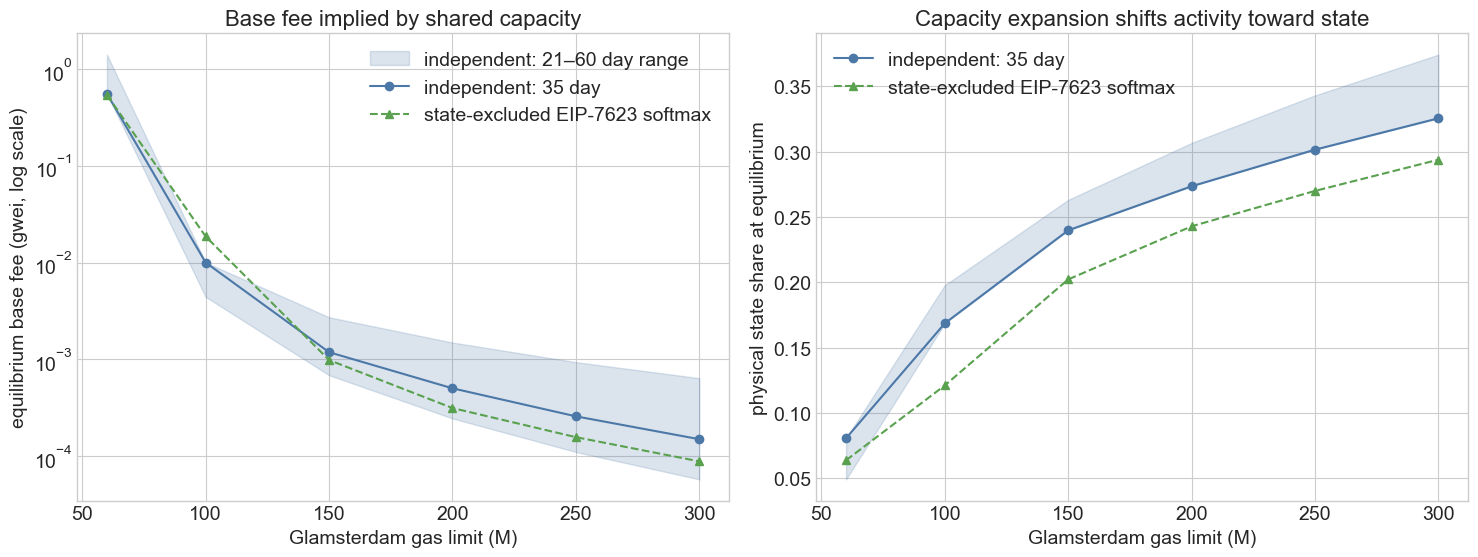

In [5]:
def curve_for(spec_name):
    return results[
        results["spec"].eq(spec_name)
        & np.isclose(results["m_execution"], CENTRAL_WORLD["m_execution"])
        & np.isclose(results["m_data"], CENTRAL_WORLD["m_data"])
        & np.isclose(results["m_state"], CENTRAL_WORLD["m_state"])
    ].sort_values("gas_limit")

independent_curves = results[
    results["demand_model"].eq("independent_isoelastic")
    & np.isclose(results["m_execution"], CENTRAL_WORLD["m_execution"])
    & np.isclose(results["m_data"], CENTRAL_WORLD["m_data"])
    & np.isclose(results["m_state"], CENTRAL_WORLD["m_state"])
]
fee_window = independent_curves.pivot(index="gas_limit", columns="window_days", values="equilibrium_base_fee_gwei").sort_index()
state_window = independent_curves.pivot(index="gas_limit", columns="window_days", values="alpha_state_equilibrium").sort_index()
central_curve = curve_for(HEADLINE_SPEC)
softmax_curve = curve_for(SOFTMAX_SPEC)
x = fee_window.index.to_numpy() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
ax = axes[0]
ax.fill_between(x, fee_window.min(axis=1).to_numpy(), fee_window.max(axis=1).to_numpy(),
                alpha=0.20, color="#4C78A8", label="independent: 21–60 day range")
ax.plot(central_curve["gas_limit"] / 1e6, central_curve["equilibrium_base_fee_gwei"],
        marker="o", color="#4C78A8", label="independent: 35 day")
ax.plot(softmax_curve["gas_limit"] / 1e6, softmax_curve["equilibrium_base_fee_gwei"],
        marker="^", linestyle="--", color="#59A14F",
        label="state-excluded EIP-7623 softmax")
ax.set_xlabel("Glamsterdam gas limit (M)")
ax.set_ylabel("equilibrium base fee (gwei, log scale)")
ax.set_yscale("log")
ax.set_title("Base fee implied by shared capacity")
ax.legend(fontsize=14)

ax = axes[1]
ax.fill_between(x, state_window.min(axis=1).to_numpy(), state_window.max(axis=1).to_numpy(),
                alpha=0.20, color="#4C78A8")
ax.plot(central_curve["gas_limit"] / 1e6, central_curve["alpha_state_equilibrium"],
        marker="o", color="#4C78A8", label="independent: 35 day")
ax.plot(softmax_curve["gas_limit"] / 1e6, softmax_curve["alpha_state_equilibrium"],
        marker="^", linestyle="--", color="#59A14F",
        label="state-excluded EIP-7623 softmax")
ax.set_xlabel("Glamsterdam gas limit (M)")
ax.set_ylabel("physical state share at equilibrium")
ax.set_title("Capacity expansion shifts activity toward state")
ax.legend(fontsize=14)
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"three_way_equilibrium_gas_limit_curves_{DATE_LABEL}.png", dpi=160)
plt.show()

## Softmax $\eta_{\text{exec}}$ Sensitivity At The Central World

This secondary sweep shows how much the aggregate-plus-softmax equilibrium
depends on the unobserved common component of the $\eta_i$ values. The x-axis
directly sweeps $\eta_{\text{execution}}$ from 0 to 0.35 and marks the value
implied by the state-excluded EIP-7623 calibration. This is diagnostic only;
the selected softmax result uses the marked calibration.

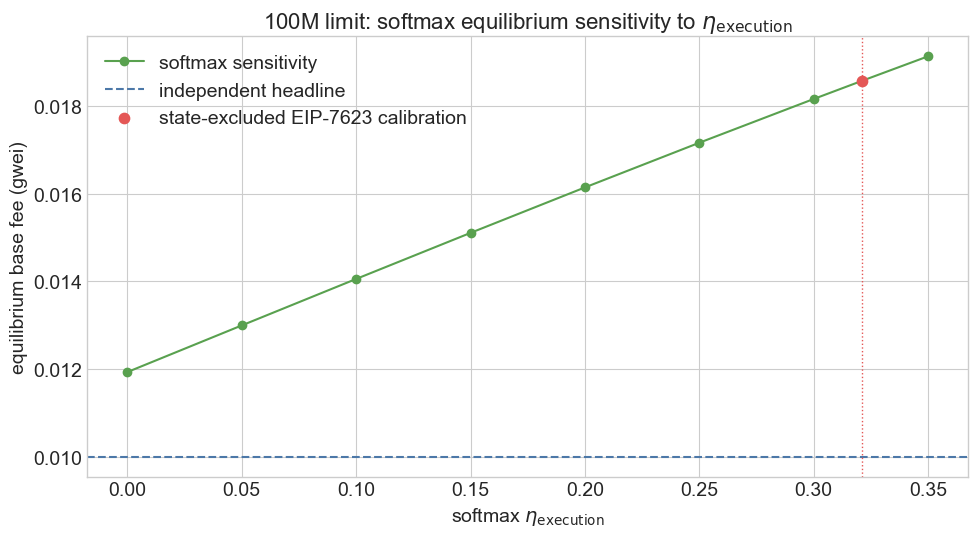

,eta_execution,eta_state,equilibrium_base_fee_gwei,binding_branch,alpha_state_equilibrium,demand_expansion
0,0.000000,0.213704,0.011931,regular,0.185934,1.295242
1,0.050000,0.263704,0.012996,regular,0.173809,1.276625
2,0.100000,0.313704,0.014057,regular,0.162512,1.259770
3,0.150000,0.363704,0.015109,regular,0.151982,1.244470
4,0.200000,0.413704,0.016148,regular,0.142160,1.230545
5,0.250000,0.463704,0.017168,regular,0.132997,1.217844
6,0.300000,0.513704,0.018168,regular,0.124443,1.206236
7,0.321101,0.534805,0.018582,regular,0.121005,1.201637
8,0.350000,0.563704,0.019143,regular,0.116456,1.195607


In [6]:
eta_exec_calibrated = float(
    parameter_card.set_index("spec").loc[SOFTMAX_SPEC, "eta_execution"]
)
eta_exec_grid = sorted(
    set(np.round(np.arange(0.0, 0.351, 0.05), 3)) | {eta_exec_calibrated}
)
trip = window_triplets.loc[35]
sweep_rows = []
for eta_exec in eta_exec_grid:
    etas = {"execution": float(eta_exec),
            "data": float(eta_exec + trip["delta_data"]),
            "state": float(eta_exec + trip["delta_state"])}
    eps = {name: etas[name] * (1 - S0[name]) + float(trip["eps_agg"]) * S0[name] for name in RESOURCES}
    spec_row = {
        "spec": f"sweep_eta_exec_{eta_exec:.2f}", "demand_model": "aggregate_plus_softmax",
        "closure": "sweep", "window_days": 35,
        "eps_agg": float(trip["eps_agg"]),
        **{f"eta_{name}": etas[name] for name in RESOURCES},
        **{f"eps_{name}": eps[name] for name in RESOURCES},
    }
    sweep_rows.append(solve_three_way(spec_row, **CENTRAL_WORLD))
eta_exec_sweep = pd.DataFrame(sweep_rows)
eta_exec_sweep.to_csv(OUT_ETA_EXEC_SWEEP_CSV, index=False)

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.plot(eta_exec_sweep["eta_execution"], eta_exec_sweep["equilibrium_base_fee_gwei"],
        marker="o", color="#59A14F", label="softmax sensitivity")
independent_fee = float(results[(results["spec"] == HEADLINE_SPEC)
                                & np.isclose(results["gas_limit"], CENTRAL_WORLD["gas_limit"])
                                & np.isclose(results["m_execution"], CENTRAL_WORLD["m_execution"])
                                & np.isclose(results["m_data"], CENTRAL_WORLD["m_data"])
                                & np.isclose(results["m_state"], CENTRAL_WORLD["m_state"])]["equilibrium_base_fee_gwei"].iloc[0])
ax.axhline(independent_fee, linestyle="--", color="#4C78A8", label="independent headline")
calibrated_row = eta_exec_sweep[np.isclose(eta_exec_sweep["eta_execution"], eta_exec_calibrated)].iloc[0]
ax.scatter([eta_exec_calibrated], [calibrated_row["equilibrium_base_fee_gwei"]],
           color="#E45756", s=55, zorder=3, label="state-excluded EIP-7623 calibration")
ax.axvline(eta_exec_calibrated, linestyle=":", color="#E45756", linewidth=1)
ax.set_xlabel(r"softmax $\eta_{\mathrm{execution}}$")
ax.set_ylabel("equilibrium base fee (gwei)")
ax.set_title(r"100M limit: softmax equilibrium sensitivity to $\eta_{\mathrm{execution}}$")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"three_way_equilibrium_eta_exec_sweep_{DATE_LABEL}.png", dpi=160)
plt.show()
eta_exec_sweep[["eta_execution", "eta_state", "equilibrium_base_fee_gwei",
                "binding_branch", "alpha_state_equilibrium", "demand_expansion"]]

## Interpretation And Scope

- **The accounting anchor is now the calibrated 120-day panel.** Current data
  gas includes EIP-7623, while the data numerator adds EIP-7976 and EIP-7981.
  State uses the scalable creation proxy under both historical and EIP-8037
  accounting, so numerator and denominator describe the same activity.
- **Execution repricing is taken from notebook 1.10.** The multiplier
  replays EIP-8038 and EIP-2780 over the same 120-day panel and reapplies the
  counterfactual refund rules transaction by transaction.
- **The independent isoelastic model is the headline.** Its three elasticities
  come from the clean gas-limit events and do not use EIP-7623.
- **The aggregate-plus-softmax model is a structural sensitivity.** It uses the
  state-excluded EIP-7623 calibration selected in notebook 1.8. The
  $\eta_{\text{execution}}$ sweep shows the consequence of moving away from it.
- The independent model assumes no cross-price substitution. The softmax model
  permits composition shifts; these are two explicit demand assumptions, not
  additional empirical estimates.
- Every equilibrium fixes metering at the 120-day protocol-accounting total
  conversions. Event-window sensitivity varies only the recovered demand elasticities.
- The main empirical limitation remains the state proxy: state gas is inferred
  from sampled block accounting rather than observed as a protocol fee meter.
- For full EIP-7999 the same demand function plugs into a three-dimension
  WorldSpec (separate execution/data/state fees); that is the next notebook's
  job, with the data-bundle composite (BAL dilution) handled explicitly.